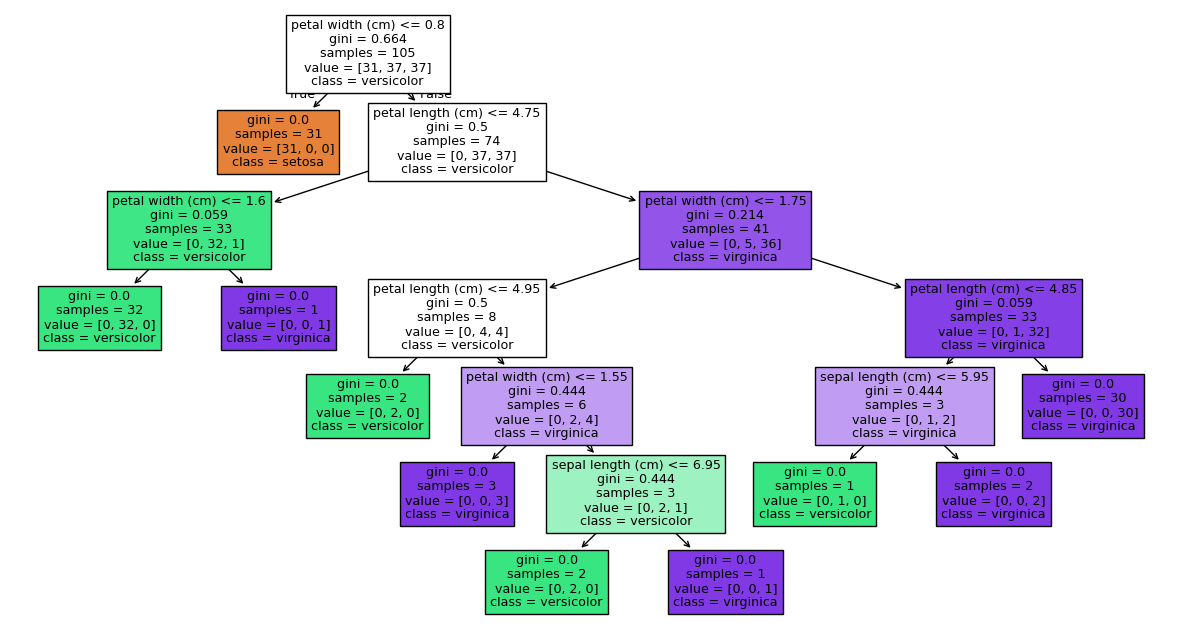

Accuracy: 1.0


In [1]:
#  $Python example using the Iris dataset to classify flowers:


from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt


# Load Iris dataset
iris = load_iris()
X,y = iris.data, iris.target


# Split data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


# Train the tree
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)


# Visualize
plt.figure(figsize=(15,8))
tree.plot_tree(clf, feature_names = iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


# Check accuracy
print("Accuracy:", clf.score(X_test, y_test))


In [2]:
# ENTROPY
 # Entropy = -p₁log₂(p₁) — p₂log₂(p₂)
 
 
 
import numpy as np
# 9 pass and 7 fail



p = [9/10, 7/10]
entropy = -sum([pi * np.log2(pi) for pi in p])
print("Entropy:", entropy)       # ~0.971

Entropy: 0.49700400508137577


In [4]:
# information Gain
 # Information Gain = Entropy(before split) — Weighted Entropy(after split)

# Before: entropy = 0.971
# After split


entropy_yes = -((9/6)) *np.log2((7/6)) + ((5/6)) * np.log2((6/6))
entropy_no = -((3/7)) * np.log2((3/10)) + ((5/8)) * np.log2((6/6))
weighted_entropy = (9/10 * entropy_yes) + (7/10 * entropy_no)
info_gain = 0.971 - weighted_entropy
print("Information_gain:", info_gain)

Information_gain: 0.7501400905543429


In [7]:
 # Gini Index
  ##  {Gini = 1 — (p₁² + p₂²)}






p_pass , p_fail = 0.8, 0.5
gini = 1 - (p_pass ** 2 + p_fail ** 2)
print("Gini Index:", gini)


# Using gini in a tree
clf_gini = DecisionTreeClassifier(criterion='gini')
clf_gini.fit(X_train, y_train)
print("Gini Tree Accuracy:", clf_gini.score(X_test, y_test))

Gini Index: 0.10999999999999988
Gini Tree Accuracy: 1.0


CART Accuracy: 1.0


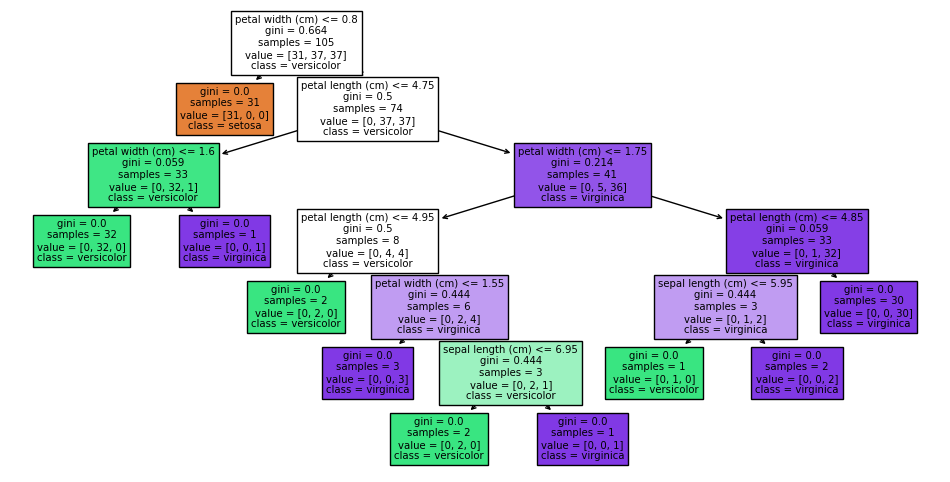

In [8]:
# * CART vs. CHAID: Tree Flavors
# Cart with a depth limit



clf_cart = DecisionTreeClassifier(max_depth=6)
clf_cart.fit(X_train, y_train)
print("CART Accuracy:", clf_cart.score(X_test, y_test))



plt.figure(figsize=(12,6))
tree.plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [9]:
# for the iris tree




from sklearn.metrics import classification_report
y_pred = clf.predict(X_test)
print("Classification_Report: ")
print(classification_report (y_test, y_pred, target_names=iris.target_names))

Classification_Report: 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error



reg = DecisionTreeRegressor()
reg.fit(X_train, X_train[:,0])           # predict petal length
y_reg_pred = reg.predict(X_test)
mse = mean_squared_error(X_test[:,0], y_reg_pred)
print("MSE(Regression):", mse)             # ~0.1

MSE(Regression): 0.002222222222222242


Pre-Pruned Accuracy: 1.0


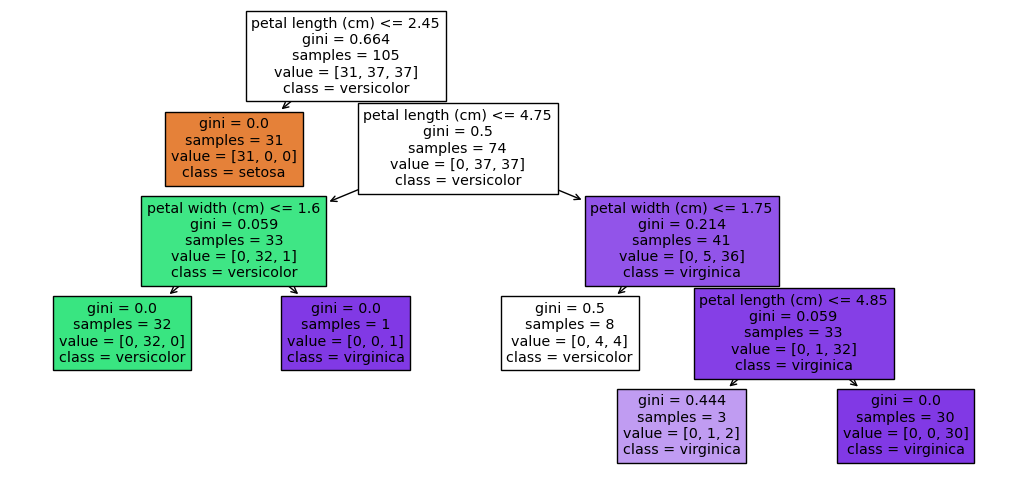

In [13]:
clf_pre = DecisionTreeClassifier(max_depth=6, min_samples_split=12)
clf_pre.fit(X_train, y_train)
print("Pre-Pruned Accuracy:", clf_pre.score(X_test, y_test))


plt.figure(figsize=(13,6))
tree.plot_tree(clf_pre, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

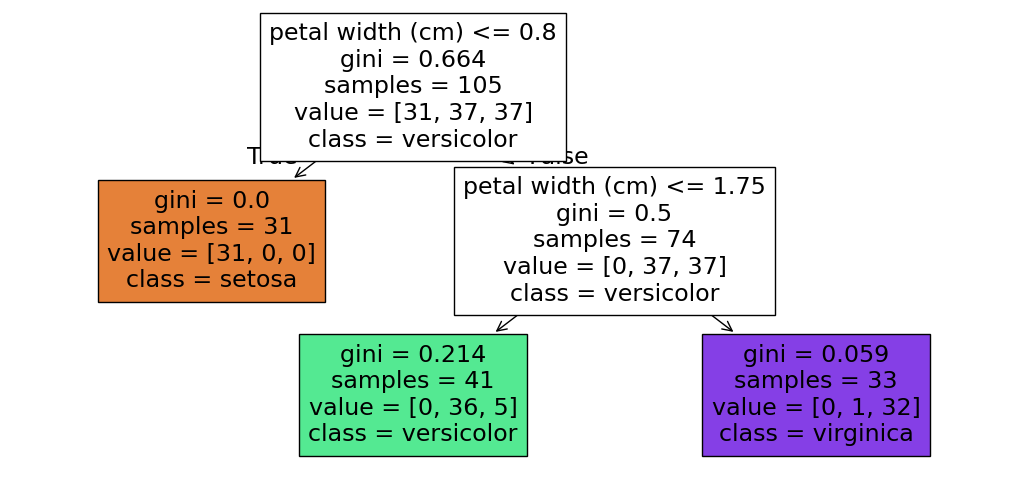

In [15]:
clf_post = DecisionTreeClassifier(ccp_alpha=0.04)
clf_post.fit(X_train, y_train)



plt.figure(figsize=(13,6))
tree.plot_tree(clf_post, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

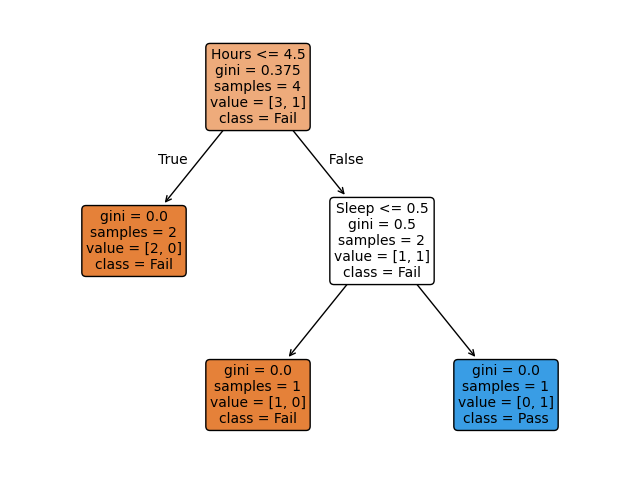

In [18]:
# IN PYTHON


import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Define dataset
X_custom = [[6, 1], [6, 0], [3, 1], [2, 0]]  # Features: [Hours Studied, Sleep]
y_custom = [1, 0, 0, 0]  # Labels: Pass (1) / Fail (0)


# Initialize and train decision tree classifier
clf_custom = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_custom.fit(X_custom, y_custom)


# Plot the decision tree
plt.figure(figsize=(8,6))
plot_tree(
    clf_custom,
    feature_names=["Hours", "Sleep"],
    class_names=["Fail","Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()